# nb30 — CCCP prior on $1{-}b$: CNC vs PS vs combined (full-sky, B=1.35 CNC sel.)

Yang26-rotated **full-sky** tSZ map + B=1.35 CNC selection mock (z ≤ 1, 10 bins):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB135_Y500c_cccp/cnc_cosmo` |
| tSZ PS only | `chains/yy_fullsky_arnaudB135_Y500c_cccp/yy` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB135_Y500c_cccp/combined` |

**Sampled:** `Omega_m`, `sigma8`, `h`, `omega_b ~ N(0.022539,0.002)`, `n_s`, **`one_minus_b ~ N(0.780,0.092)`** (CCCP), `alpha_SZ ~ N(1.12,0.05)`, `sigma_lnY ~ N(0.173,0.023)`

**Derived:** `B = 1/(1-b)`

**Fixed:** `A_SZ`, `tau_reio`, `m_nu` (CNC/combined only)

A **B=1 CNC selection** section below adds `cnc_cosmo_arnaudB1_Y500c_cccp` and `cnc_yy_combined_fullsky_arnaudB1_Y500c_cccp`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

from getdist import loadMCSamples, plots

REPO = "/scratch/scratch-lxu/flamingo_repo"
OUTDIR = os.path.join(REPO, "figures", "nb30_fullsky_cccp_contours")
os.makedirs(OUTDIR, exist_ok=True)

N_QGT5_B135 = 768
N_QGT5_B1 = 2023
OM_TRUTH, S8_TRUTH = 0.306, 0.808
A_SZ_FIXED = -4.28739604
LOAD_SETTINGS = {"ignore_rows": 0.1}
R1_TARGET = 0.05

RUNS_B135 = [
    dict(
        tag="cnc",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB135_Y500c_cccp", "cnc_cosmo"),
        label="CNC only",
        color="#d62728",
        run_hint="bash cobaya/run_cnc_cosmo_B135_cccp.sh",
    ),
    dict(
        tag="yy",
        path=os.path.join(REPO, "chains", "yy_fullsky_arnaudB135_Y500c_cccp", "yy"),
        label="tSZ PS only",
        color="#2ca02c",
        run_hint="bash cobaya/run_yy_fullsky_B135_cccp.sh",
    ),
    dict(
        tag="comb",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB135_Y500c_cccp", "combined"),
        label="CNC + full-sky PS",
        color="#8c564b",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B135_cccp.sh",
    ),
]

RUNS_B1 = [
    dict(
        tag="cnc",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB1_Y500c_cccp", "cnc_cosmo"),
        label="CNC only",
        color="#d62728",
        run_hint="bash cobaya/run_cnc_cosmo_B1_Y500c_cccp.sh",
    ),
    dict(
        tag="yy",
        path=os.path.join(REPO, "chains", "yy_fullsky_arnaudB135_Y500c_cccp", "yy"),
        label="tSZ PS only",
        color="#2ca02c",
        run_hint="bash cobaya/run_yy_fullsky_B135_cccp.sh",
    ),
    dict(
        tag="comb",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB1_Y500c_cccp", "combined"),
        label="CNC + full-sky PS",
        color="#8c564b",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B1_Y500c_cccp.sh",
    ),
]

TRUTH = {
    "Omega_m": OM_TRUTH, "sigma8": S8_TRUTH,
    "S8": S8_TRUTH * np.sqrt(OM_TRUTH / 0.3),
    "F": S8_TRUTH * (OM_TRUTH / 1.35) ** 0.40 * 0.681 ** (-0.21),
    "h": 0.681, "omega_b": 0.022539, "n_s": 0.967,
    "alpha_SZ": 1.12, "sigma_lnY": 0.173, "B": 1.35, "one_minus_b": 0.780,
}
CHAIN_PARS = ["Omega_m", "sigma8", "h", "omega_b", "n_s", "alpha_SZ", "B", "sigma_lnY"]
DERIVED_PARS = ["S8", "F"]
COSMO_PARS = ["Omega_m", "sigma8", "S8", "F"]
PARS_PRINT = CHAIN_PARS[:2] + DERIVED_PARS + CHAIN_PARS[2:]
FIXED_PARS = {"A_SZ": A_SZ_FIXED}


def _add_derived(sample):
    p = sample.getParams()
    sample.addDerived(
        p.sigma8 * np.sqrt(p.Omega_m / 0.3), name="S8", label=r"S_8",
    )
    h = getattr(p, "h", 0.681)
    sample.addDerived(
        p.sigma8 * (p.Omega_m / p.B) ** 0.40 * h ** (-0.21), name="F", label=r"F",
    )
    return sample


def _load_chain(path, label, run_hint, *, n_qgt5, tag):
    if not os.path.exists(path + ".1.txt"):
        print(f"MISSING: {path}")
        print(f"  run: {run_hint}")
        return None
    sample = loadMCSamples(path, settings=LOAD_SETTINGS)
    sample = _add_derived(sample)
    r1 = getattr(sample, "Rminus1", None)
    print(f"\n{label}: {sample.numrows} post-discard samples", end="")
    if r1 is not None:
        flag = " (converged)" if r1 <= R1_TARGET else " (running)"
        print(f"; R-1={r1:.3f}{flag}", end="")
    print()
    names = set(sample.getParamNames().list())
    print(f"{label} — {tag} mock (N={n_qgt5}):")
    for nm in PARS_PRINT:
        if nm in names:
            print(f"  {nm:12s} = {sample.mean(nm):.4f} +/- {sample.std(nm):.4f}")
    for nm, val in FIXED_PARS.items():
        print(f"  {nm:12s} = {val:.6f} (fixed)")
    return sample


def load_runs(runs, *, n_qgt5, tag):
    loaded = {}
    for run in runs:
        s = _load_chain(run["path"], run["label"], run["run_hint"], n_qgt5=n_qgt5, tag=tag)
        if s is not None:
            loaded[run["tag"]] = s
    return loaded


def chains_from_runs(runs, loaded):
    return [loaded[r["tag"]] for r in runs if r["tag"] in loaded]


def labels_colors_from_runs(runs, loaded):
    labels = [r["label"] for r in runs if r["tag"] in loaded]
    colors = [r["color"] for r in runs if r["tag"] in loaded]
    return labels, colors


loaded_b135 = load_runs(RUNS_B135, n_qgt5=N_QGT5_B135, tag="B=1.35 CNC sel.")
RUNS = RUNS_B135
loaded = loaded_b135

if len(loaded) >= 2:
    for tag_a, tag_b, key in [("cnc", "comb", "S8"), ("yy", "comb", "S8"), ("cnc", "comb", "B")]:
        if tag_a in loaded and tag_b in loaded:
            la = next(r["label"] for r in RUNS if r["tag"] == tag_a)
            lb = next(r["label"] for r in RUNS if r["tag"] == tag_b)
            print(f"Δ{key} ({lb} − {la}) = {loaded[tag_b].mean(key) - loaded[tag_a].mean(key):+.4f}")

chains = chains_from_runs(RUNS_B135, loaded_b135)
labels = labels_colors_from_runs(RUNS_B135, loaded_b135)[0]
colors = labels_colors_from_runs(RUNS_B135, loaded_b135)[1]

if len(chains) < 2:
    print("\nNeed at least two chains for contour plots.")
else:
    names = [set(s.getParamNames().list()) for s in chains]
    full_pars = CHAIN_PARS[:2] + DERIVED_PARS + CHAIN_PARS[2:]
    plot_pars = [p for p in full_pars if all(p in n for n in names)]
    cosmo_pars = [p for p in COSMO_PARS if all(p in n for n in names)]



CNC only: 4644 post-discard samples
CNC only — B=1.35 CNC sel. mock (N=768):
  Omega_m      = 0.3005 +/- 0.0169
  sigma8       = 0.7435 +/- 0.0230
  S8           = 0.7437 +/- 0.0278
  F            = 0.4481 +/- 0.0034
  h            = 0.6830 +/- 0.0238
  omega_b      = 0.0224 +/- 0.0019
  n_s          = 0.9675 +/- 0.0138
  alpha_SZ     = 1.1022 +/- 0.0411
  B            = 1.3048 +/- 0.1315
  sigma_lnY    = 0.1729 +/- 0.0240
  A_SZ         = -4.287396 (fixed)

tSZ PS only: 9432 post-discard samples
tSZ PS only — B=1.35 CNC sel. mock (N=768):
  Omega_m      = 0.3664 +/- 0.0655
  sigma8       = 0.8065 +/- 0.0533
  S8           = 0.8838 +/- 0.0551
  F            = 0.5213 +/- 0.0052
  h            = 0.6839 +/- 0.0227
  omega_b      = 0.0225 +/- 0.0020
  n_s          = 0.9676 +/- 0.0138
  alpha_SZ     = 1.1066 +/- 0.0485
  B            = 1.3108 +/- 0.1432
  sigma_lnY    = 0.1738 +/- 0.0235
  A_SZ         = -4.287396 (fixed)
/scratch/scratch-lxu/flamingo_repo/chains/cnc_yy_combined_fullsky_ar

## Triangle: cosmology + S8, F + nuisances (CCCP $1{-}b$ prior)

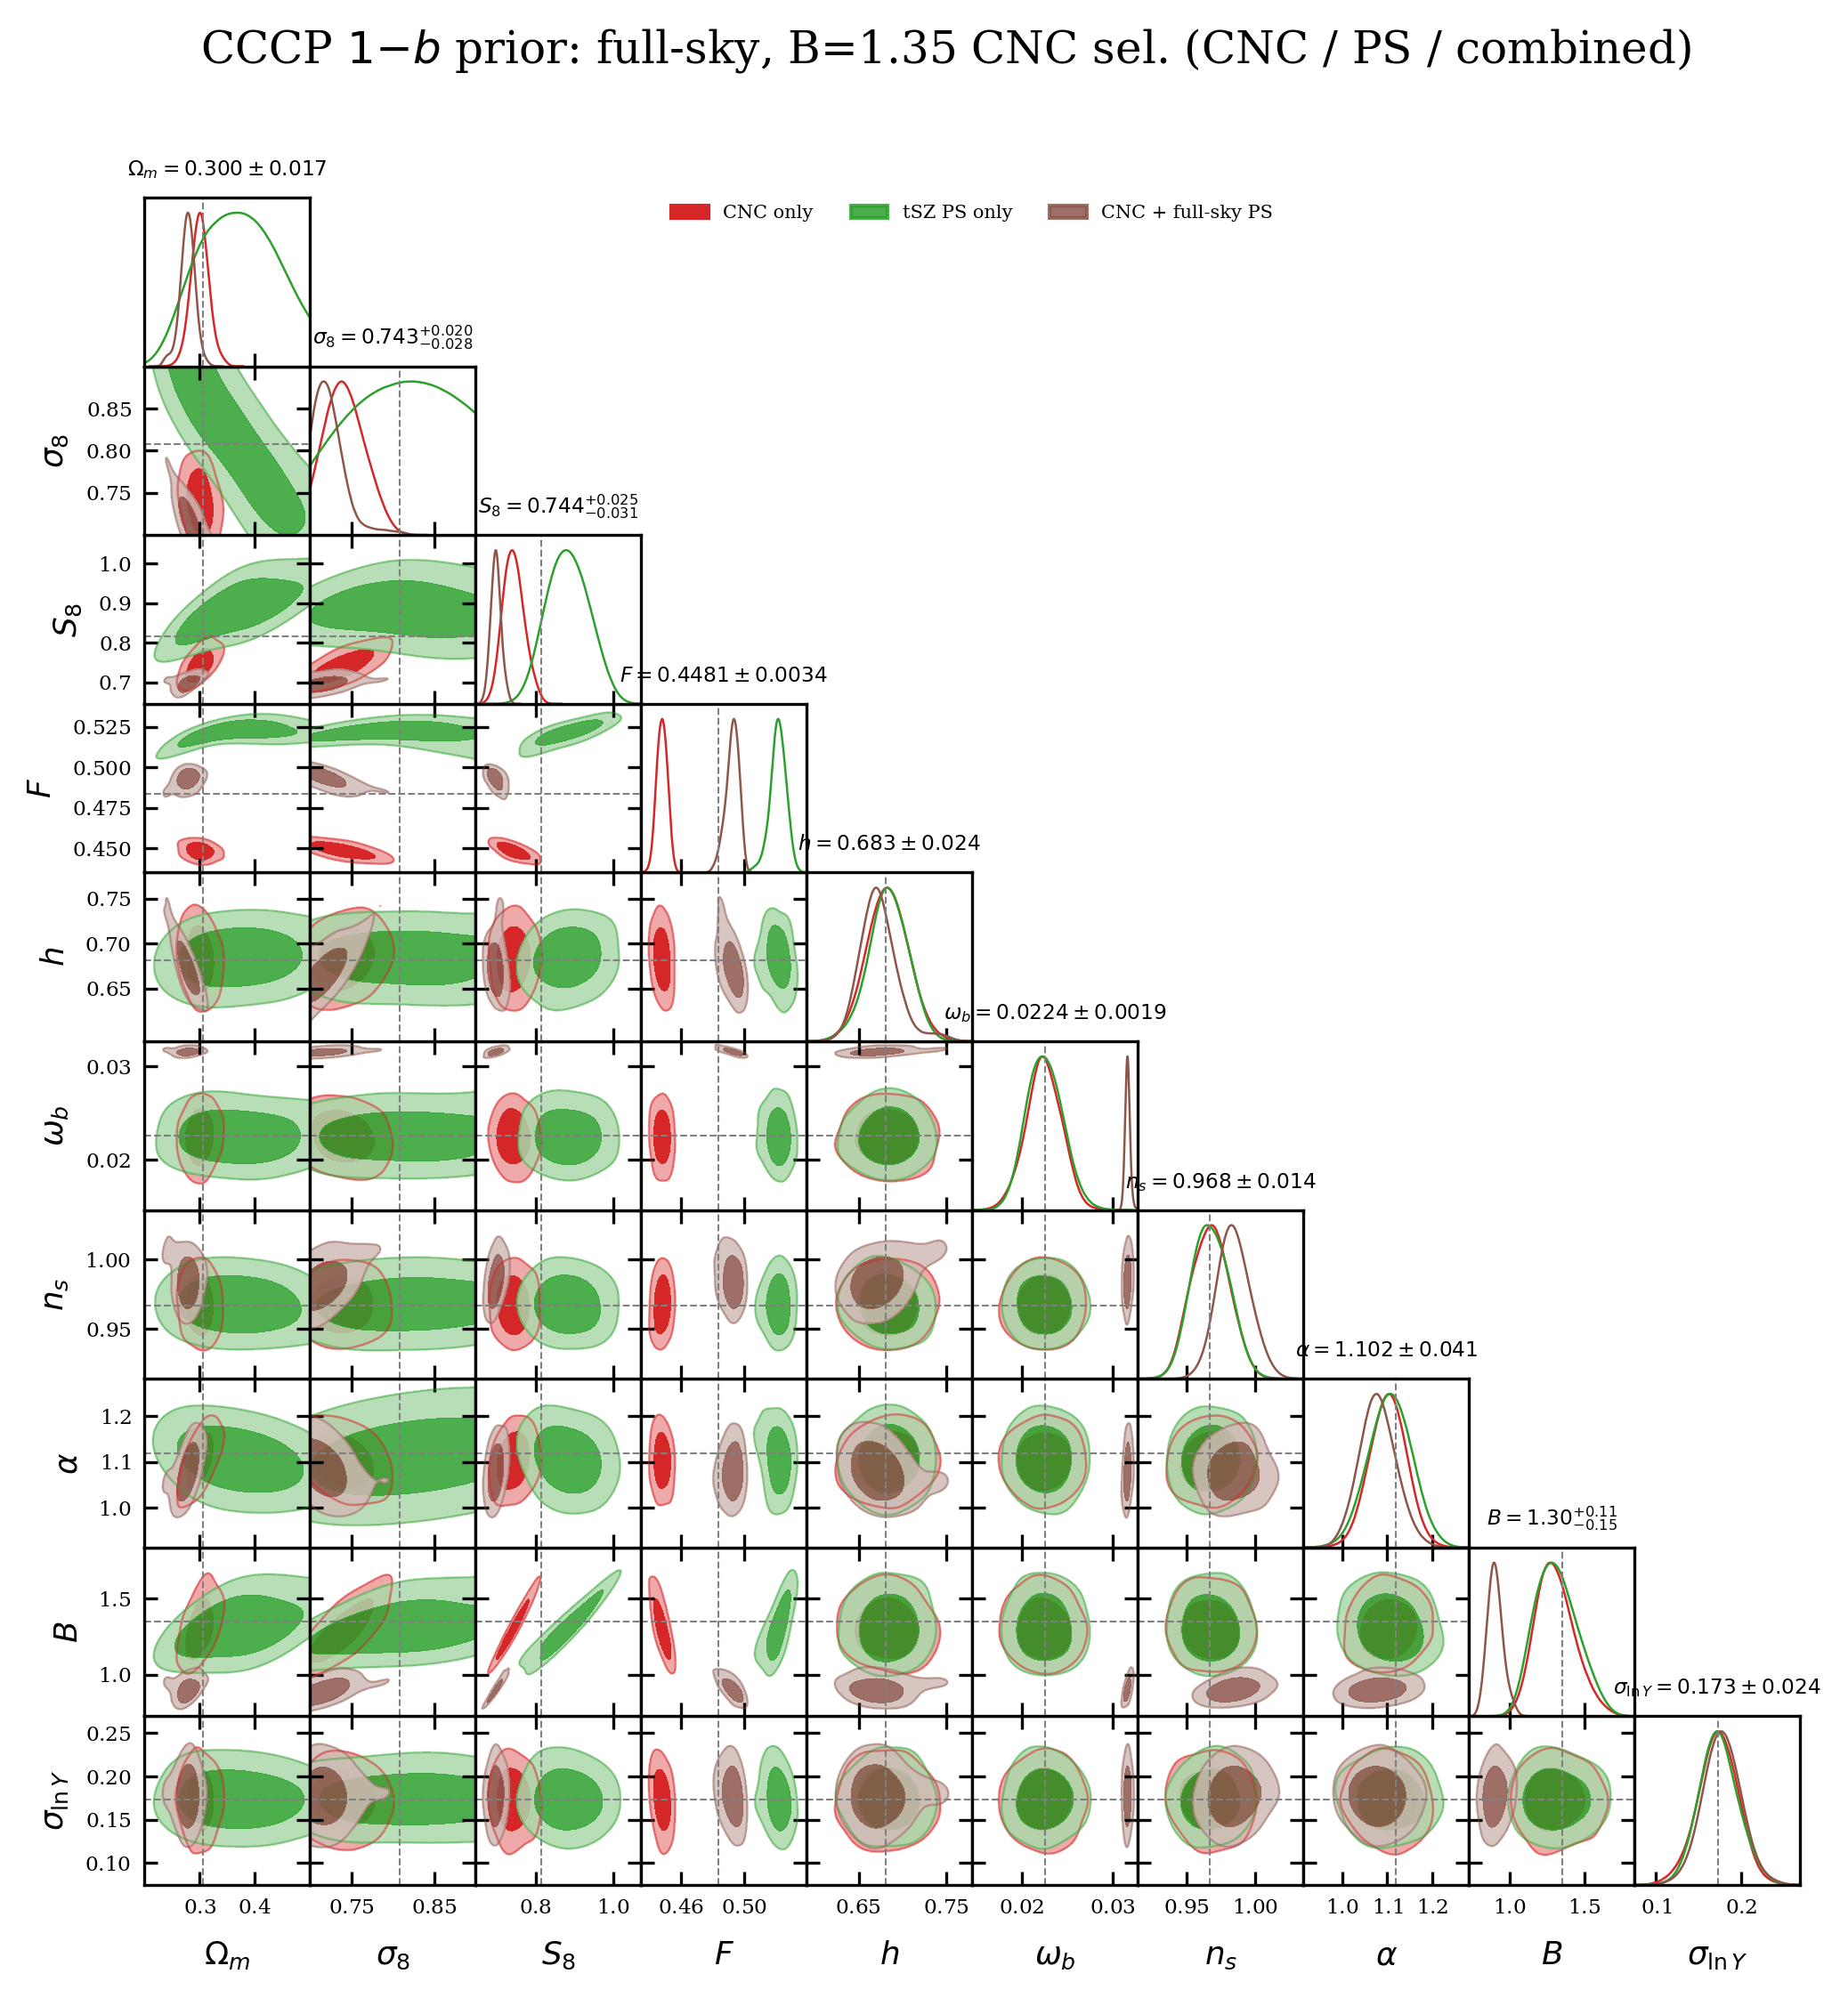

In [2]:
if len(chains) >= 2 and plot_pars:
    g = plots.get_subplot_plotter(width_inch=8)
    g.settings.legend_fontsize = 10
    g.settings.figure_legend_frame = False
    g.triangle_plot(
        chains, plot_pars, filled=True, contour_colors=colors,
        legend_labels=labels, legend_loc="upper center", legend_ncol=3,
        title_limit=1, markers={k: TRUTH[k] for k in plot_pars if k in TRUTH},
    )
    g.fig.suptitle(
        r"CCCP $1{-}b$ prior: full-sky, B=1.35 CNC sel. (CNC / PS / combined)",
        fontsize=12,
    )
    g.fig.subplots_adjust(top=0.90)
    g.export(os.path.join(OUTDIR, "fullsky_cccp_triangle.pdf"))
    g.export(os.path.join(OUTDIR, "fullsky_cccp_triangle.png"), dpi=300)
    plt.show()
else:
    print("Triangle skipped.")


## Ω_m–σ_8 plane

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb30_fullsky_cccp_contours


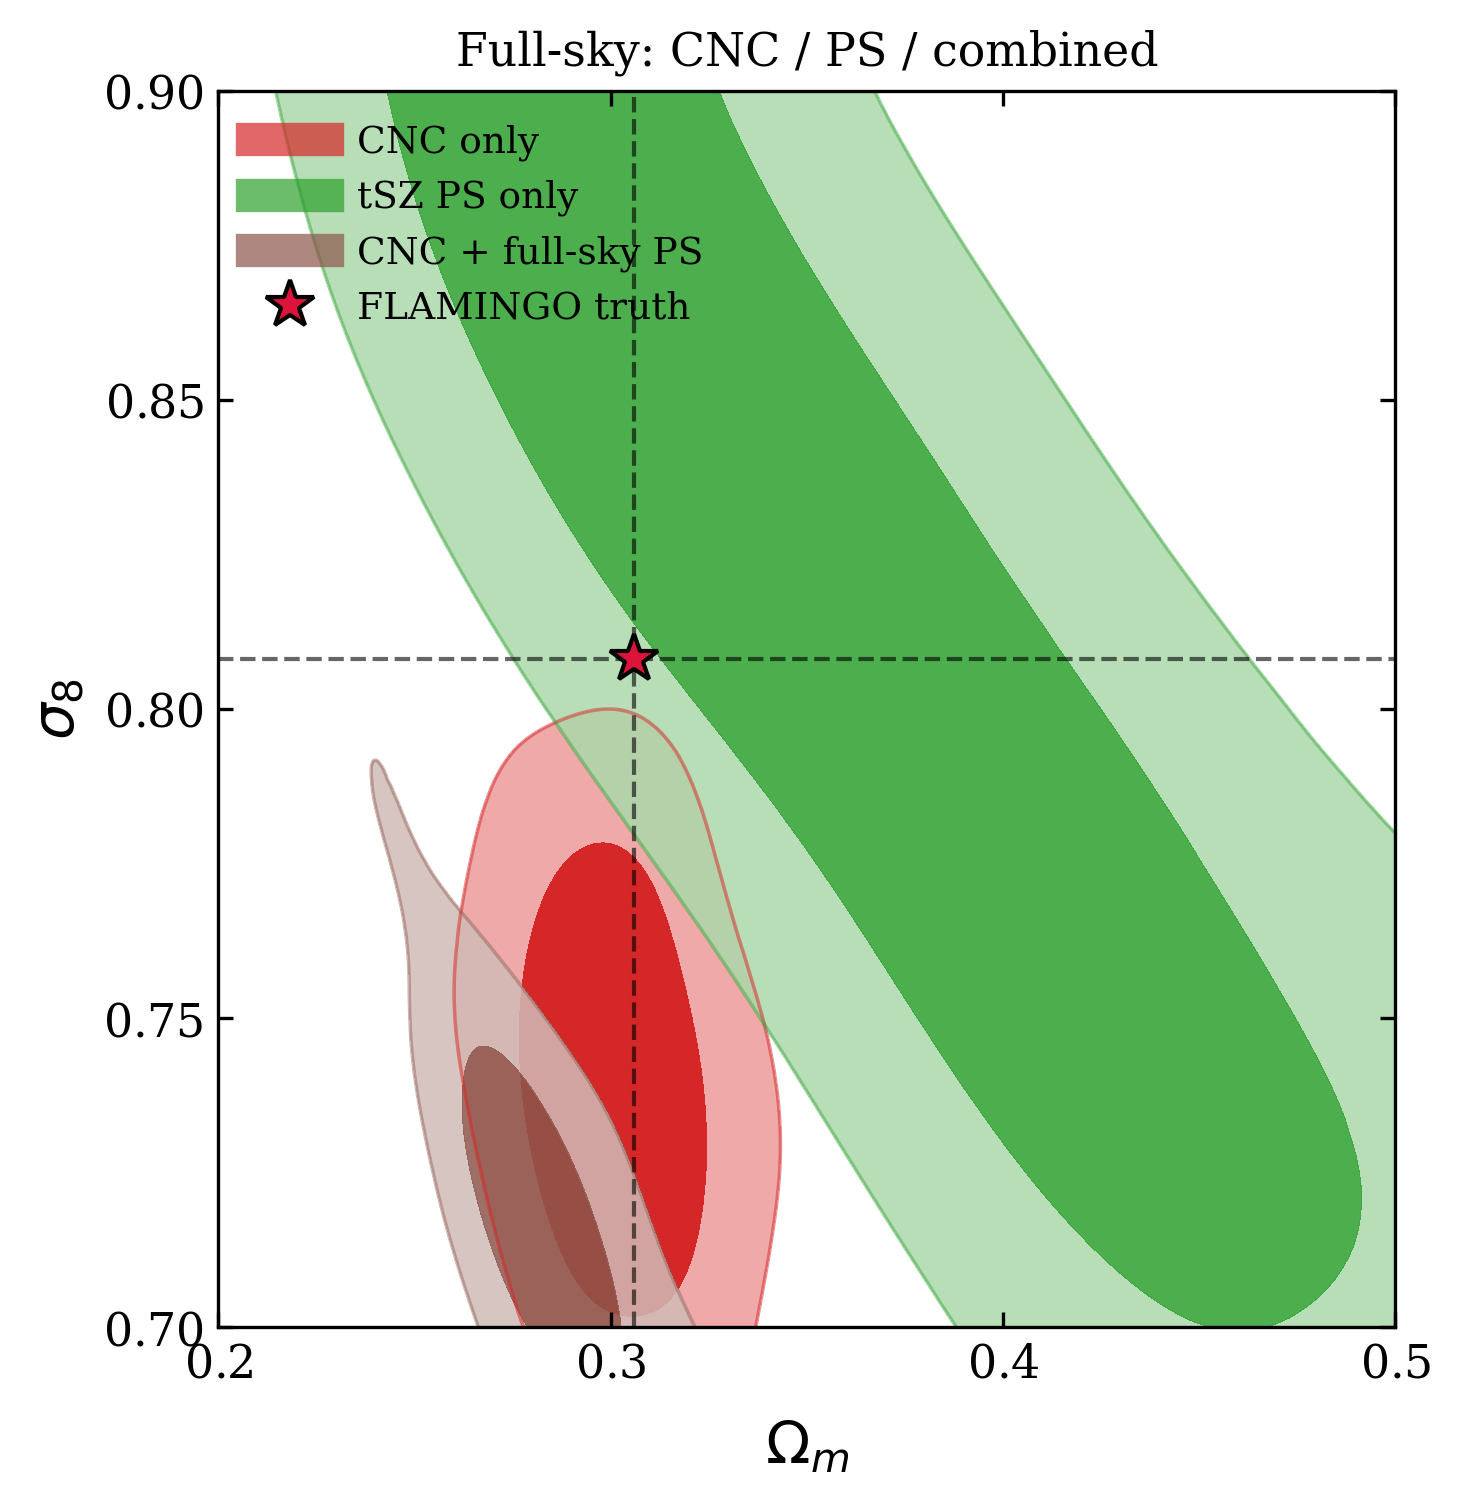

In [3]:
from matplotlib.lines import Line2D

if len(chains) >= 2:
    g2 = plots.get_subplot_plotter(width_inch=5)
    g2.plot_2d(chains, "Omega_m", "sigma8", filled=True, colors=colors)
    ax = plt.gca()
    ax.plot(OM_TRUTH, S8_TRUTH, "*", color="crimson", ms=12, mec="k", zorder=10)
    ax.axvline(OM_TRUTH, color="k", ls="--", lw=1, alpha=0.6)
    ax.axhline(S8_TRUTH, color="k", ls="--", lw=1, alpha=0.6)
    handles = [
        Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
        for c, l in zip(colors, labels)
    ] + [
        Line2D([], [], color="crimson", marker="*", ls="", ms=12, mec="k", label="FLAMINGO truth"),
    ]
    ax.legend(handles=handles, fontsize=9, loc="upper left", frameon=False)
    ax.set_title(r"Full-sky: CNC / PS / combined", fontsize=11)
    g2.export(os.path.join(OUTDIR, "fullsky_cccp_Om_s8_plane.pdf"))
    g2.export(os.path.join(OUTDIR, "fullsky_cccp_Om_s8_plane.png"), dpi=300)
    print("saved ->", OUTDIR)
    plt.show()
else:
    print("Ωm–σ8 plane skipped.")


---

## B=1 CNC selection mock (same CCCP + Gaussian $\omega_b$ priors)

Two extra chains with `N2d_z_q_bin_arnaudB1_Y500c.txt` ($N_{q>5}=2023$).
tSZ PS chain is unchanged (same full-sky bandpowers as B=1.35 section).


In [4]:
loaded_b1 = load_runs(RUNS_B1, n_qgt5=N_QGT5_B1, tag="B=1 CNC sel.")

if len(loaded_b1) >= 2:
    for tag_a, tag_b, key in [("cnc", "comb", "S8"), ("yy", "comb", "S8"), ("cnc", "comb", "B")]:
        if tag_a in loaded_b1 and tag_b in loaded_b1:
            la = next(r["label"] for r in RUNS_B1 if r["tag"] == tag_a)
            lb = next(r["label"] for r in RUNS_B1 if r["tag"] == tag_b)
            print(f"Δ{key} ({lb} − {la}) = {loaded_b1[tag_b].mean(key) - loaded_b1[tag_a].mean(key):+.4f}")

chains_b1 = chains_from_runs(RUNS_B1, loaded_b1)
labels_b1, colors_b1 = labels_colors_from_runs(RUNS_B1, loaded_b1)

if len(chains_b1) >= 2:
    names_b1 = [set(s.getParamNames().list()) for s in chains_b1]
    plot_pars_b1 = [p for p in (CHAIN_PARS[:2] + DERIVED_PARS + CHAIN_PARS[2:]) if all(p in n for n in names_b1)]
else:
    plot_pars_b1 = []
    print("Need at least two B=1 chains for contour plots.")



CNC only: 5940 post-discard samples
CNC only — B=1 CNC sel. mock (N=2023):
  Omega_m      = 0.3101 +/- 0.0129
  sigma8       = 0.8191 +/- 0.0246
  S8           = 0.8327 +/- 0.0318
  F            = 0.4976 +/- 0.0027
  h            = 0.6791 +/- 0.0220
  omega_b      = 0.0226 +/- 0.0019
  n_s          = 0.9660 +/- 0.0129
  alpha_SZ     = 1.1226 +/- 0.0382
  B            = 1.3255 +/- 0.1345
  sigma_lnY    = 0.1770 +/- 0.0236
  A_SZ         = -4.287396 (fixed)

tSZ PS only: 9432 post-discard samples
tSZ PS only — B=1 CNC sel. mock (N=2023):
  Omega_m      = 0.3664 +/- 0.0655
  sigma8       = 0.8065 +/- 0.0533
  S8           = 0.8838 +/- 0.0551
  F            = 0.5213 +/- 0.0052
  h            = 0.6839 +/- 0.0227
  omega_b      = 0.0225 +/- 0.0020
  n_s          = 0.9676 +/- 0.0138
  alpha_SZ     = 1.1066 +/- 0.0485
  B            = 1.3108 +/- 0.1432
  sigma_lnY    = 0.1738 +/- 0.0235
  A_SZ         = -4.287396 (fixed)

CNC + full-sky PS: 6912 post-discard samples
CNC + full-sky PS — B=1 CN

### Triangle: B=1 CNC selection


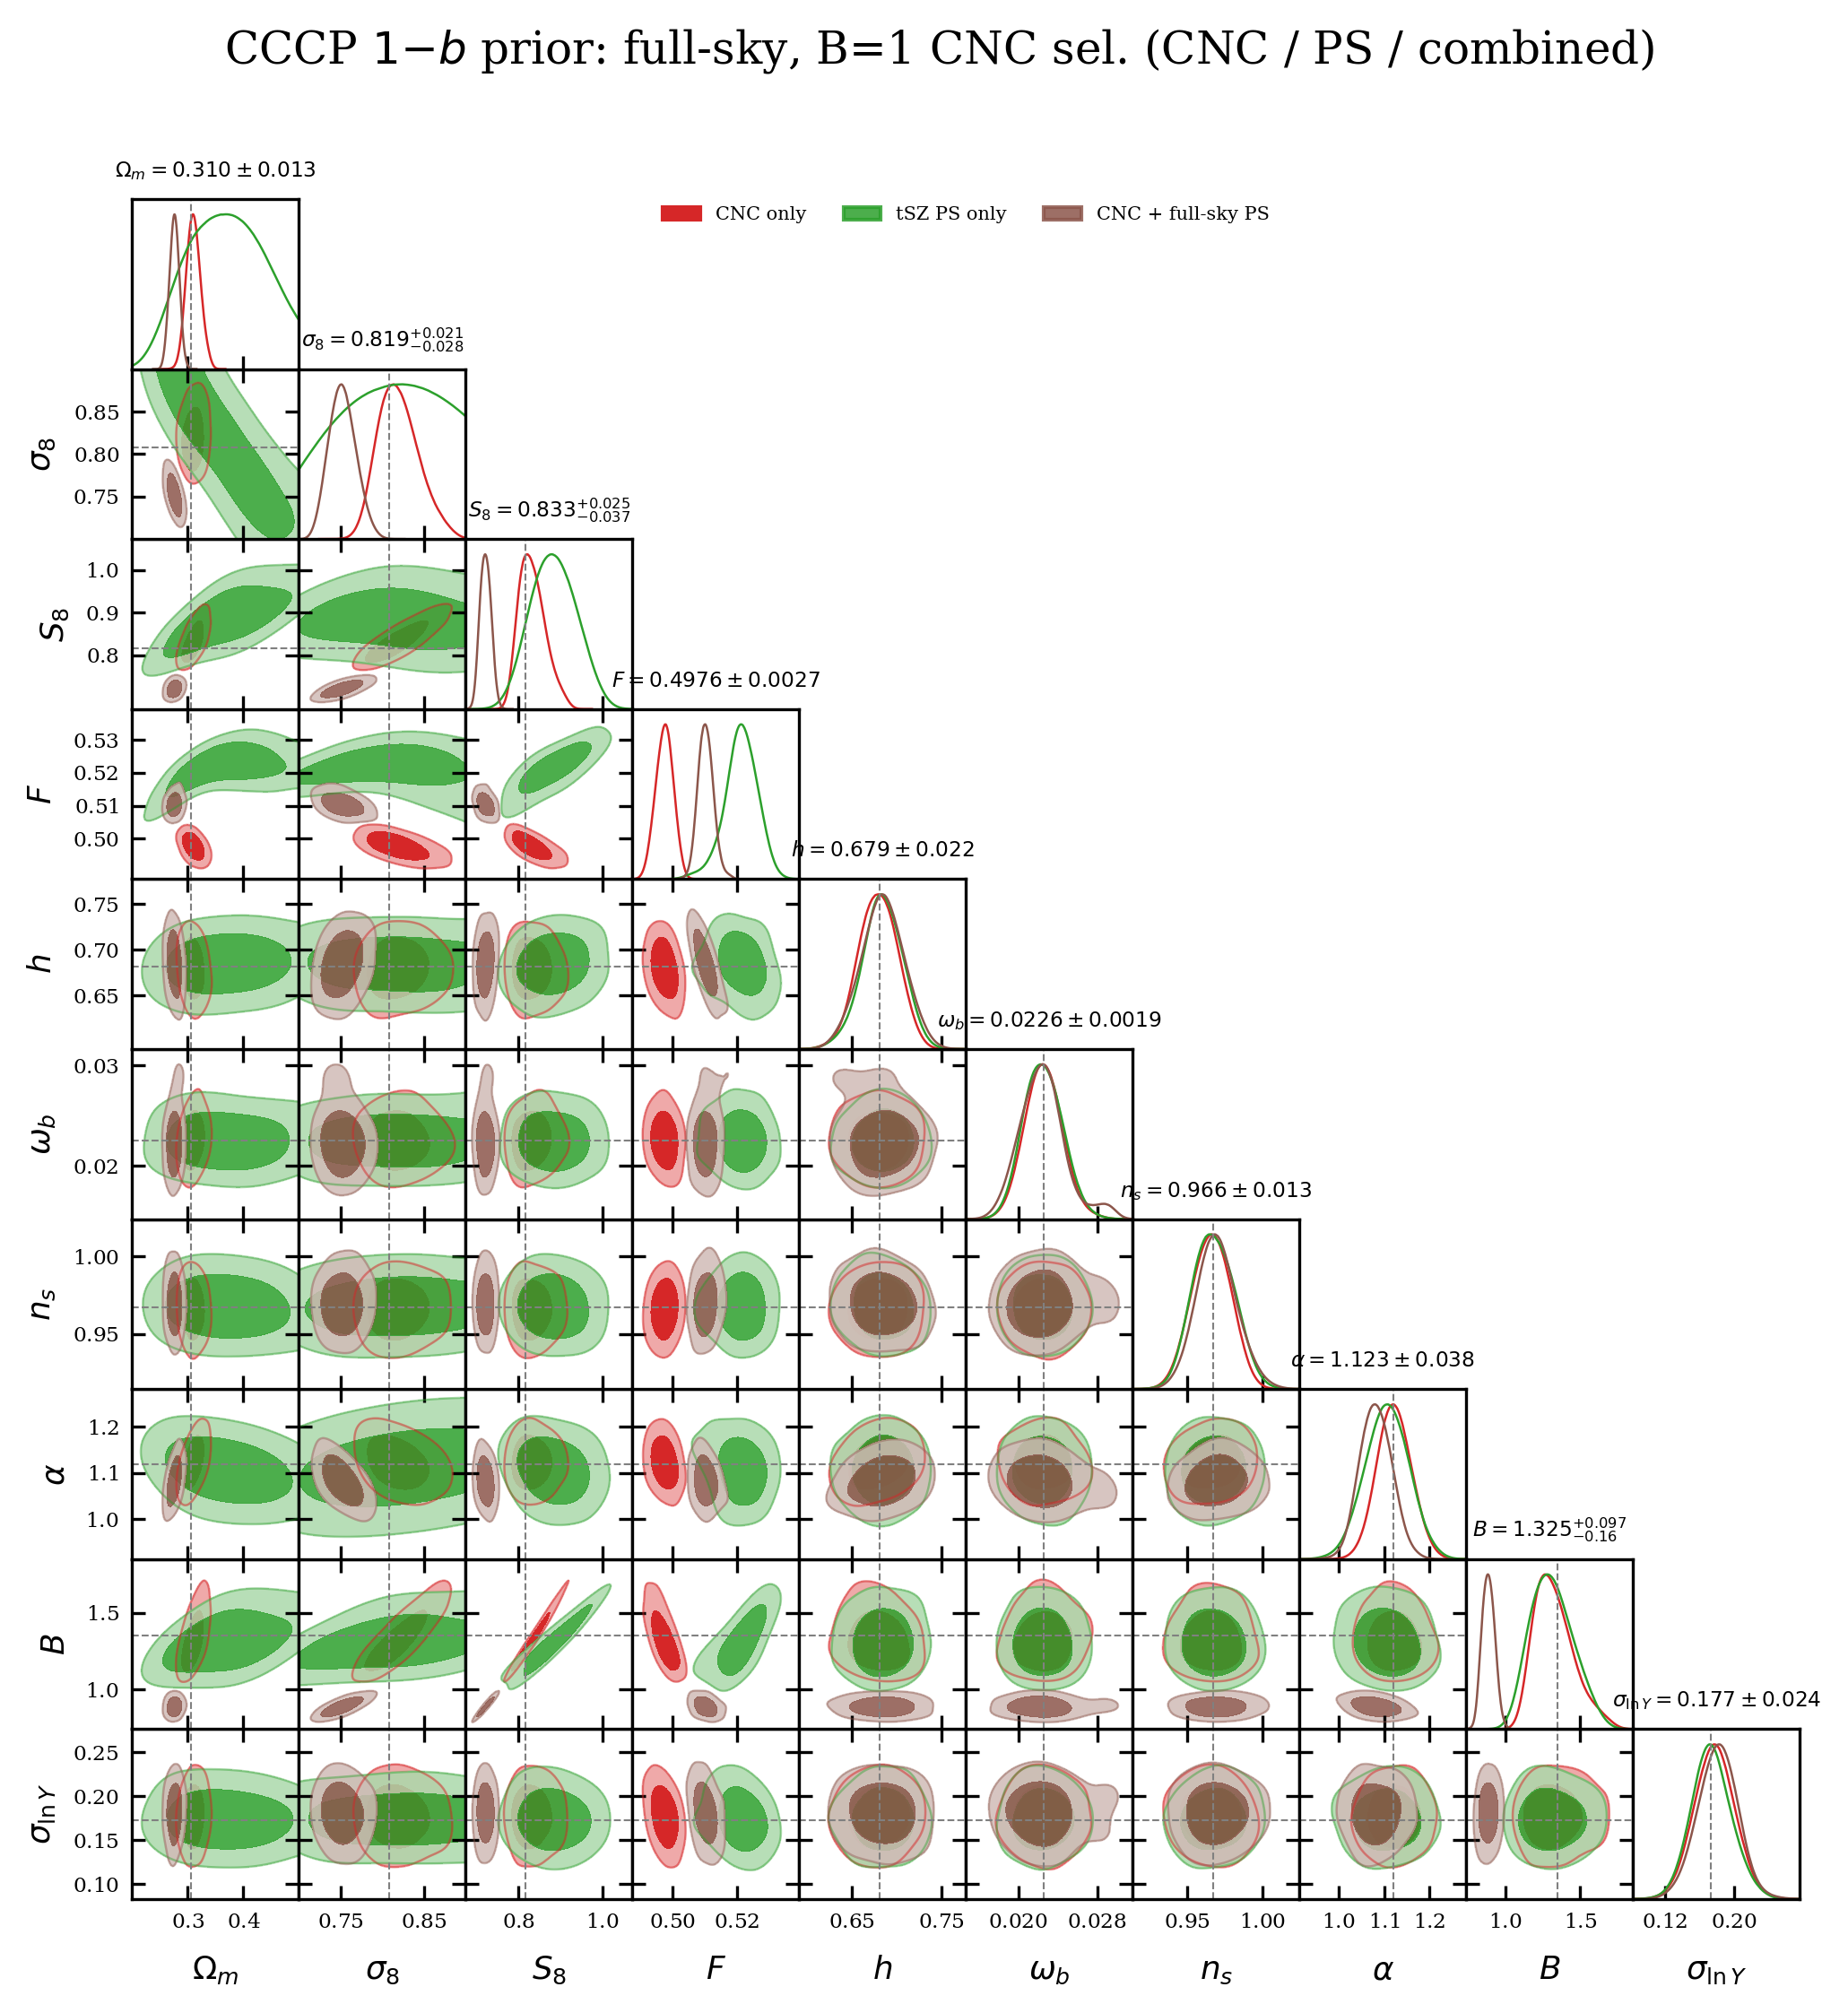

In [5]:
if len(chains_b1) >= 2 and plot_pars_b1:
    g_b1 = plots.get_subplot_plotter(width_inch=8)
    g_b1.settings.legend_fontsize = 10
    g_b1.settings.figure_legend_frame = False
    g_b1.triangle_plot(
        chains_b1, plot_pars_b1, filled=True, contour_colors=colors_b1,
        legend_labels=labels_b1, legend_loc="upper center", legend_ncol=3,
        title_limit=1, markers={k: TRUTH[k] for k in plot_pars_b1 if k in TRUTH},
    )
    g_b1.fig.suptitle(
        r"CCCP $1{-}b$ prior: full-sky, B=1 CNC sel. (CNC / PS / combined)",
        fontsize=12,
    )
    g_b1.fig.subplots_adjust(top=0.90)
    g_b1.export(os.path.join(OUTDIR, "fullsky_cccp_triangle_B1.pdf"))
    g_b1.export(os.path.join(OUTDIR, "fullsky_cccp_triangle_B1.png"), dpi=300)
    plt.show()
else:
    print("B=1 triangle skipped.")


### $\Omega_m$–$\sigma_8$ plane: B=1 CNC selection


saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb30_fullsky_cccp_contours


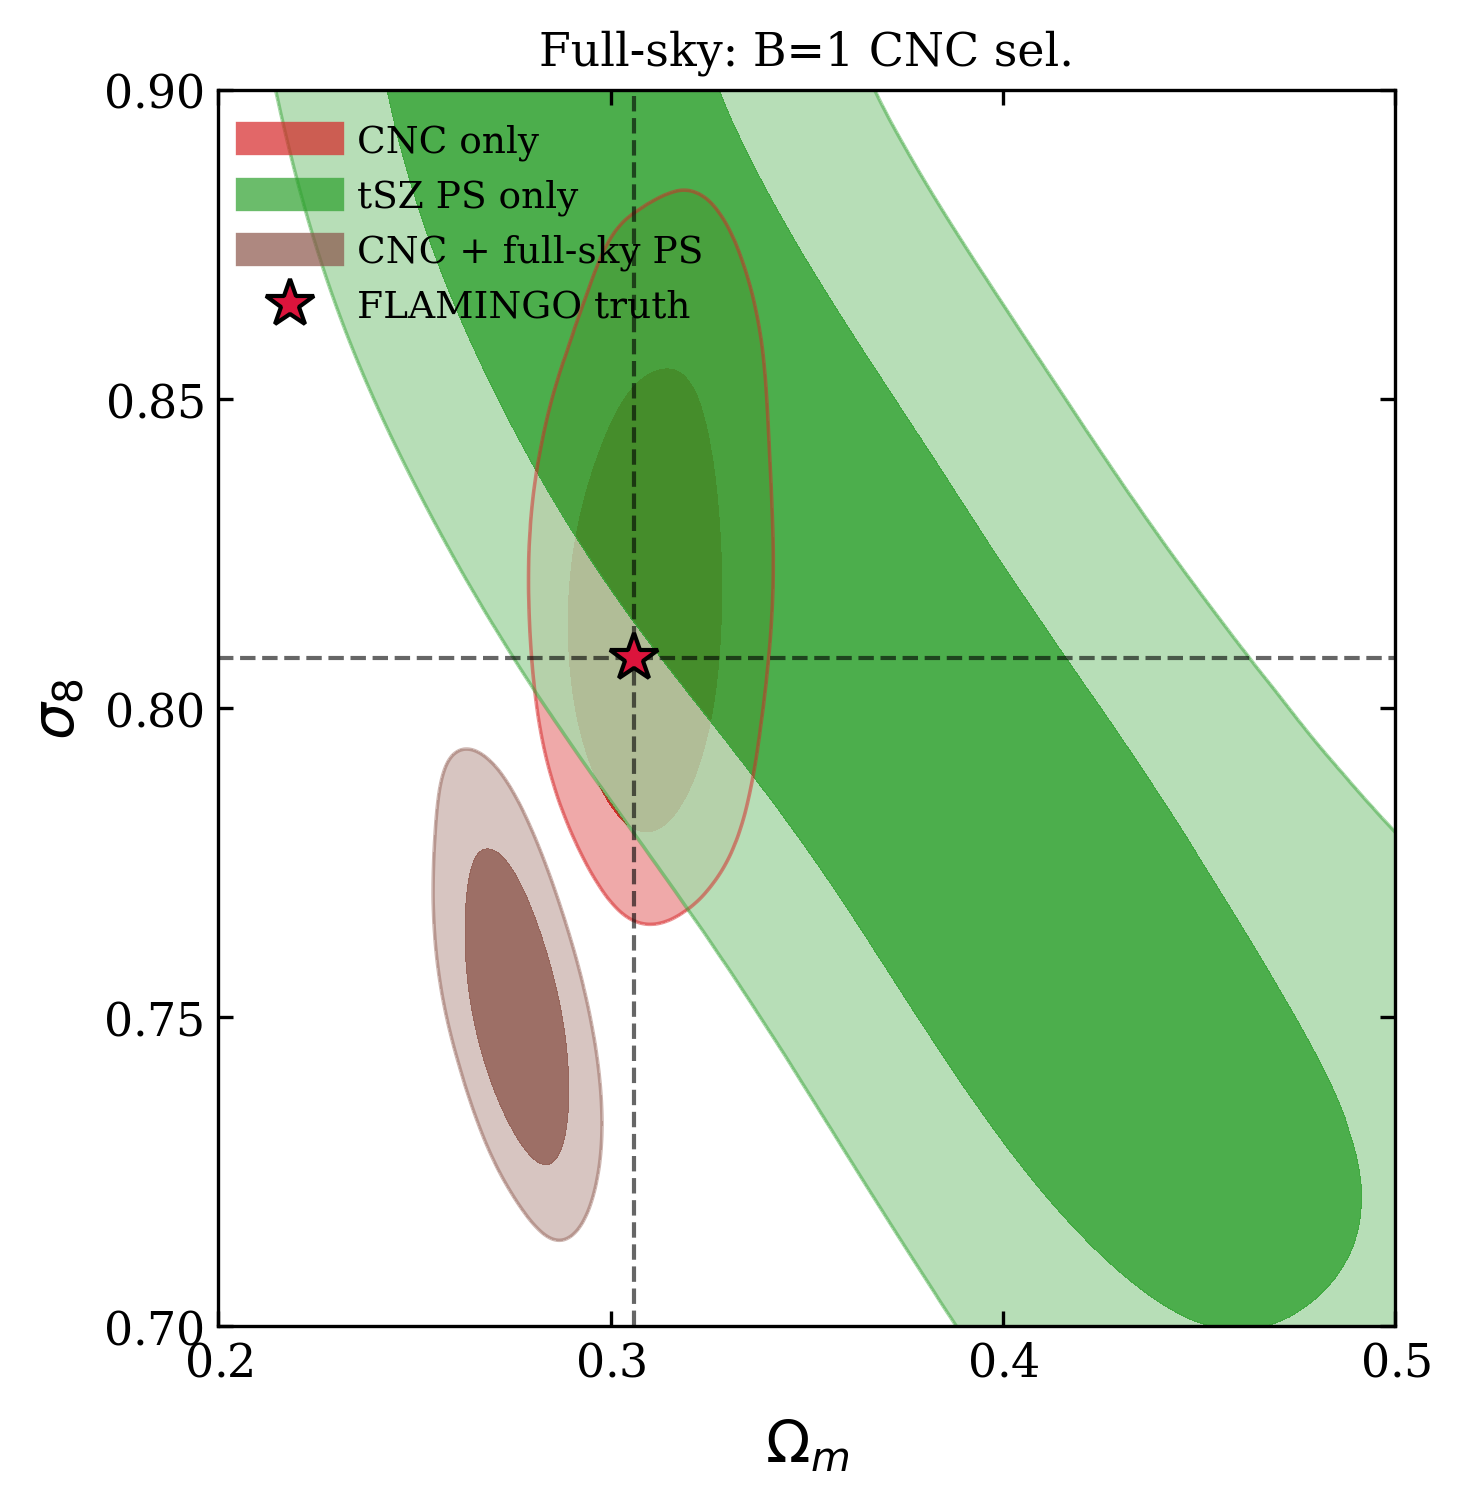

In [6]:
from matplotlib.lines import Line2D

if len(chains_b1) >= 2:
    g2_b1 = plots.get_subplot_plotter(width_inch=5)
    g2_b1.plot_2d(chains_b1, "Omega_m", "sigma8", filled=True, colors=colors_b1)
    ax = plt.gca()
    ax.plot(OM_TRUTH, S8_TRUTH, "*", color="crimson", ms=12, mec="k", zorder=10)
    ax.axvline(OM_TRUTH, color="k", ls="--", lw=1, alpha=0.6)
    ax.axhline(S8_TRUTH, color="k", ls="--", lw=1, alpha=0.6)
    handles = [
        Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
        for c, l in zip(colors_b1, labels_b1)
    ] + [
        Line2D([], [], color="crimson", marker="*", ls="", ms=12, mec="k", label="FLAMINGO truth"),
    ]
    ax.legend(handles=handles, fontsize=9, loc="upper left", frameon=False)
    ax.set_title(r"Full-sky: B=1 CNC sel.", fontsize=11)
    g2_b1.export(os.path.join(OUTDIR, "fullsky_cccp_Om_s8_plane_B1.pdf"))
    g2_b1.export(os.path.join(OUTDIR, "fullsky_cccp_Om_s8_plane_B1.png"), dpi=300)
    print("saved ->", OUTDIR)
    plt.show()
else:
    print("B=1 Ωm–σ8 plane skipped.")
